# Deriving Slow Features for Affect Modelling

## Environment Setup

This notebook computes slow features using the MDP library, which requires `numpy < 1.24`.  
This is **incompatible** with scikit-learn, so we use a dedicated conda environment (`sfa_env`).

**Before running**, create and activate the environment:

```bash
conda env create -f env_sfa.yaml
conda activate sfa_env
```

## Overview

We derive three types of SFA representations, each at multiple output dimensions (5, 10, 15, 20, 25, 30):

1. **Slow linear features** — SFA applied directly to raw features
2. **Slow degree 2 features** — PCA reduction + polynomial expansion (degree 2) + whitening + SFA
3. **Slow degree 3 features** — PCA reduction + polynomial expansion (degree 3) + whitening + SFA

For degree 2 and 3, the polynomial expansion creates a rank-deficient covariance matrix.  
A `WhiteningNode` is inserted before SFA to project out near-zero variance directions.  
A `PCANode` is placed in front of both polynomial expansions to keep the expanded space  
computationally tractable: with the full 288 raw features, a direct degree-2 expansion  
would produce ~41,900 features (covariance matrix ≈ 14 GB) and a direct degree-3 expansion  
would produce millions. PCA reduction to a manageable dimension before the expansion keeps  
each expanded space in the few-thousand-feature range.

All extracted features are saved to `features/` for downstream use.

In [1]:
import numpy as np
import mdp
import os

print("NumPy version:", np.__version__)
print("MDP version:", mdp.__version__)

NumPy version: 1.23.5
MDP version: 3.6


## 1. Load Preprocessed Data

We load the standardised features saved by Notebook 1, along with participant IDs.  
For now we use only the **audio features** (columns 0–136) to establish the framework,  
before expanding to the full 288-feature set.

In [2]:
# Load standardised features from Notebook 1
X_all = np.load("features/raw_features.npy")
participant_ids = np.load("features/participant_ids.npy")

# Select audio features only (first 137 columns) for initial framework
# Set AUDIO_ONLY = False to use the full feature set
AUDIO_ONLY = False
if AUDIO_ONLY:
    X_scaled = X_all[:, :137]
    feature_label = "audio"
else:
    X_scaled = X_all
    feature_label = "all"

print(f"Feature set: {feature_label}")
print(f"X shape: {X_scaled.shape}")
print(f"Participants: {np.unique(participant_ids)}")
print(f"Samples per participant:")
for pid in np.unique(participant_ids):
    print(f"  P{int(pid)}: {np.sum(participant_ids == pid)} samples")

Feature set: all
X shape: (13066, 288)
Participants: [16 19 21 23 25 26 28 30 34 37 39 41 42 45 46 56 64 65]
Samples per participant:
  P16: 729 samples
  P19: 715 samples
  P21: 734 samples
  P23: 728 samples
  P25: 725 samples
  P26: 728 samples
  P28: 729 samples
  P30: 738 samples
  P34: 693 samples
  P37: 731 samples
  P39: 726 samples
  P41: 733 samples
  P42: 737 samples
  P45: 718 samples
  P46: 715 samples
  P56: 731 samples
  P64: 725 samples
  P65: 731 samples


## 2. Configuration

In [3]:
output_dims = [5, 10, 15, 20, 25, 30]

# PCA reduction is applied before each polynomial expansion to keep the expanded
# feature space computationally tractable. Without this, a degree-2 expansion of
# the 288 raw features would produce ~41,900 features (cov matrix ~14 GB) and a
# degree-3 expansion would produce millions.
#
# Degree 2: PCA to 100 components -> ~5,150 expanded features (cov matrix ~210 MB)
# Degree 3: PCA to 30  components -> ~5,455 expanded features (cov matrix ~240 MB)
PCA_DIM_FOR_DEG2 = 100
PCA_DIM_FOR_DEG3 = 30

# Storage for all extracted features
slow_linear_features = {}
slow_deg2_features = {}
slow_deg3_features = {}

## 3. Slow Linear Features

Linear SFA applies the slow feature objective directly to the standardised input.  
This finds the linear projections whose outputs change most slowly over time.

In [4]:
for n_dim in output_dims:
    sfa_node = mdp.nodes.SFANode(output_dim=n_dim)
    sfa_node.train(X_scaled)
    sfa_node.stop_training()

    slow_features = sfa_node.execute(X_scaled)
    slow_linear_features[n_dim] = slow_features

    # Compute delta values (slowness): mean squared temporal difference per component
    deltas = np.mean(np.diff(slow_features, axis=0) ** 2, axis=0)

    print(f"\nSlow Linear Features - {n_dim} components")
    print(f"  Output shape: {slow_features.shape}")
    print(f"  Delta values: {np.round(deltas, 6)}")
    print(f"  Mean delta:   {np.mean(deltas):.6f}")

print("\nSlow linear feature extraction complete.")


Slow Linear Features - 5 components
  Output shape: (13066, 5)
  Delta values: [0.003056 0.010357 0.015011 0.017287 0.017527]
  Mean delta:   0.012647

Slow Linear Features - 10 components
  Output shape: (13066, 10)
  Delta values: [0.003056 0.010357 0.015011 0.017287 0.017527 0.019664 0.021758 0.02292
 0.025006 0.026506]
  Mean delta:   0.017909

Slow Linear Features - 15 components
  Output shape: (13066, 15)
  Delta values: [0.003056 0.010357 0.015011 0.017287 0.017527 0.019664 0.021758 0.02292
 0.025006 0.026506 0.028569 0.029372 0.029655 0.030744 0.032488]
  Mean delta:   0.021995

Slow Linear Features - 20 components
  Output shape: (13066, 20)
  Delta values: [0.003056 0.010357 0.015011 0.017287 0.017527 0.019664 0.021758 0.02292
 0.025006 0.026506 0.028569 0.029372 0.029655 0.030744 0.032488 0.033953
 0.03485  0.037037 0.037921 0.038618]
  Mean delta:   0.025615

Slow Linear Features - 25 components
  Output shape: (13066, 25)
  Delta values: [0.003056 0.010357 0.015011 0.017

## 4. Slow Degree 2 Features

Polynomial expansion (degree 2) introduces nonlinearity by adding all pairwise  
products and squared terms. Applied directly to the full 288 raw features it would  
produce ~41,900 expanded features — a covariance matrix of ~14 GB, which exceeds  
typical RAM. We therefore reduce to `PCA_DIM_FOR_DEG2` components first, producing  
~5,150 expanded features (covariance matrix ~210 MB). The expanded space is still  
rank-deficient, so a `WhiteningNode` is placed between expansion and SFA to remove  
near-zero variance directions.

Flow: `PCA(PCA_DIM_FOR_DEG2)` → `PolynomialExpansion(2)` → `Whitening` → `SFA`

In [5]:
for n_dim in output_dims:
    pca_node = mdp.nodes.PCANode(output_dim=PCA_DIM_FOR_DEG2)
    expansion_node = mdp.nodes.PolynomialExpansionNode(2)
    whitening_node = mdp.nodes.WhiteningNode(svd=True)
    sfa_node = mdp.nodes.SFANode(output_dim=n_dim)

    flow = mdp.Flow([pca_node, expansion_node, whitening_node, sfa_node])
    flow.train(X_scaled)
    slow_features = flow.execute(X_scaled)
    slow_deg2_features[n_dim] = slow_features

    deltas = np.mean(np.diff(slow_features, axis=0) ** 2, axis=0)

    print(f"\nSlow Degree 2 Features - {n_dim} components")
    print(f"  Output shape: {slow_features.shape}")
    print(f"  Delta values: {np.round(deltas, 6)}")
    print(f"  Mean delta:   {np.mean(deltas):.6f}")

print("\nSlow degree 2 feature extraction complete.")


Slow Degree 2 Features - 5 components
  Output shape: (13066, 5)
  Delta values: [0.004004 0.007174 0.008278 0.008917 0.010357]
  Mean delta:   0.007746

Slow Degree 2 Features - 10 components
  Output shape: (13066, 10)
  Delta values: [0.004004 0.007174 0.008278 0.008917 0.010357 0.011038 0.011303 0.011451
 0.011617 0.011908]
  Mean delta:   0.009605

Slow Degree 2 Features - 15 components
  Output shape: (13066, 15)
  Delta values: [0.004004 0.007174 0.008278 0.008917 0.010357 0.011038 0.011303 0.011451
 0.011617 0.011908 0.01231  0.012858 0.013229 0.013934 0.014371]
  Mean delta:   0.010850

Slow Degree 2 Features - 20 components
  Output shape: (13066, 20)
  Delta values: [0.004004 0.007174 0.008278 0.008917 0.010357 0.011038 0.011303 0.011451
 0.011617 0.011908 0.01231  0.012858 0.013229 0.013934 0.014371 0.014424
 0.014994 0.015142 0.015887 0.016021]
  Mean delta:   0.011961

Slow Degree 2 Features - 25 components
  Output shape: (13066, 25)
  Delta values: [0.004004 0.007174 0

## 5. Slow Degree 3 Features

Degree 3 polynomial expansion on the full 288 raw features would produce millions  
of expanded dimensions, which is infeasible. We first reduce to `PCA_DIM_FOR_DEG3`  
components (~5,455 expanded features at degree 3, manageable with 13k samples).

Flow: `PCA(PCA_DIM_FOR_DEG3)` → `PolynomialExpansion(3)` → `Whitening` → `SFA`

In [6]:
slow_deg3_features = {}

for n_dim in output_dims:
    pca_node = mdp.nodes.PCANode(output_dim=PCA_DIM_FOR_DEG3)
    expansion_node = mdp.nodes.PolynomialExpansionNode(3)
    whitening_node = mdp.nodes.WhiteningNode(svd=True)
    sfa_node = mdp.nodes.SFANode(output_dim=n_dim, rank_deficit_method='auto')

    flow = mdp.Flow([pca_node, expansion_node, whitening_node, sfa_node])
    flow.train(X_scaled)
    slow_features = flow.execute(X_scaled)
    slow_deg3_features[n_dim] = slow_features

    deltas = np.mean(np.diff(slow_features, axis=0) ** 2, axis=0)

    print(f"\nSlow Degree 3 Features - {n_dim} components")
    print(f"  Output shape: {slow_features.shape}")
    print(f"  Delta values: {np.round(deltas, 6)}")
    print(f"  Mean delta:   {np.mean(deltas):.6f}")

print("\nSlow degree 3 feature extraction complete.")


Slow Degree 3 Features - 5 components
  Output shape: (13066, 5)
  Delta values: [0.006992 0.010342 0.011778 0.012647 0.015216]
  Mean delta:   0.011395

Slow Degree 3 Features - 10 components
  Output shape: (13066, 10)
  Delta values: [0.006992 0.010342 0.011778 0.012647 0.015216 0.015712 0.016174 0.016677
 0.017413 0.018595]
  Mean delta:   0.014155

Slow Degree 3 Features - 15 components
  Output shape: (13066, 15)
  Delta values: [0.006992 0.010342 0.011778 0.012647 0.015216 0.015712 0.016174 0.016677
 0.017413 0.018595 0.019197 0.019903 0.020438 0.02169  0.022014]
  Mean delta:   0.016319

Slow Degree 3 Features - 20 components
  Output shape: (13066, 20)
  Delta values: [0.006992 0.010342 0.011778 0.012647 0.015216 0.015712 0.016174 0.016677
 0.017413 0.018595 0.019197 0.019903 0.020438 0.02169  0.022014 0.022689
 0.023153 0.023458 0.023988 0.024724]
  Mean delta:   0.018140

Slow Degree 3 Features - 25 components
  Output shape: (13066, 25)
  Delta values: [0.006992 0.010342 0

## 6. Visualisation

### 6a. Slowness Comparison Across Methods

Compare delta values (mean squared temporal difference) across all three methods.  
Lower delta = slower, more invariant features.

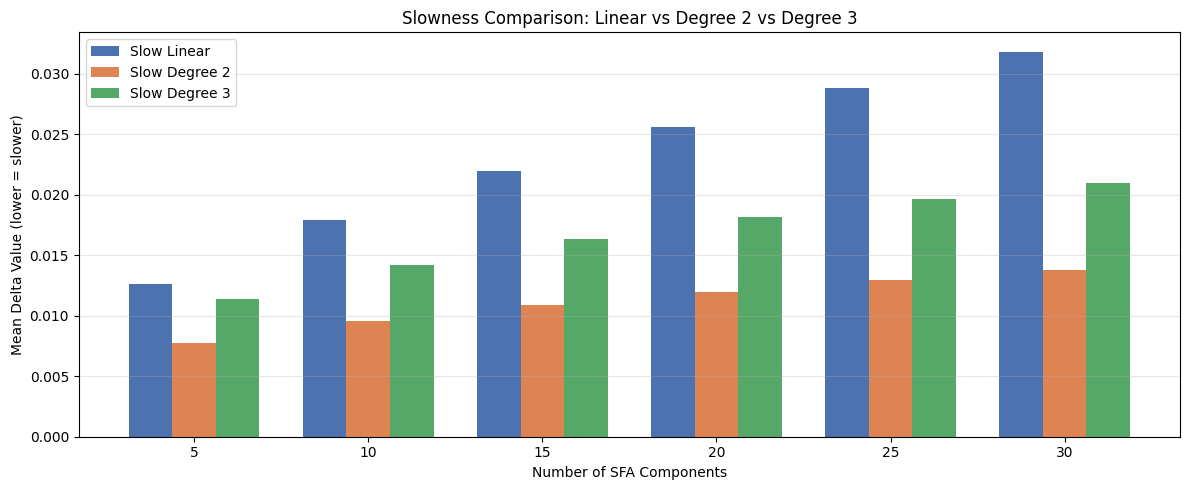

In [7]:
import matplotlib.pyplot as plt

linear_deltas = []
deg2_deltas = []
deg3_deltas = []

for n_dim in output_dims:
    linear_deltas.append(np.mean(np.diff(slow_linear_features[n_dim], axis=0) ** 2))
    deg2_deltas.append(np.mean(np.diff(slow_deg2_features[n_dim], axis=0) ** 2))
    deg3_deltas.append(np.mean(np.diff(slow_deg3_features[n_dim], axis=0) ** 2))

x = np.arange(len(output_dims))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, linear_deltas, width, label="Slow Linear", color="#4C72B0")
ax.bar(x, deg2_deltas, width, label="Slow Degree 2", color="#DD8452")
ax.bar(x + width, deg3_deltas, width, label="Slow Degree 3", color="#55A868")

ax.set_xlabel("Number of SFA Components")
ax.set_ylabel("Mean Delta Value (lower = slower)")
ax.set_title("Slowness Comparison: Linear vs Degree 2 vs Degree 3")
ax.set_xticks(x)
ax.set_xticklabels(output_dims)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("features/slowness_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 6b. Temporal Profiles

Compare the first 3 slow features from each method against raw features  
for a single participant. Slow features should show smooth, slowly-varying trajectories.

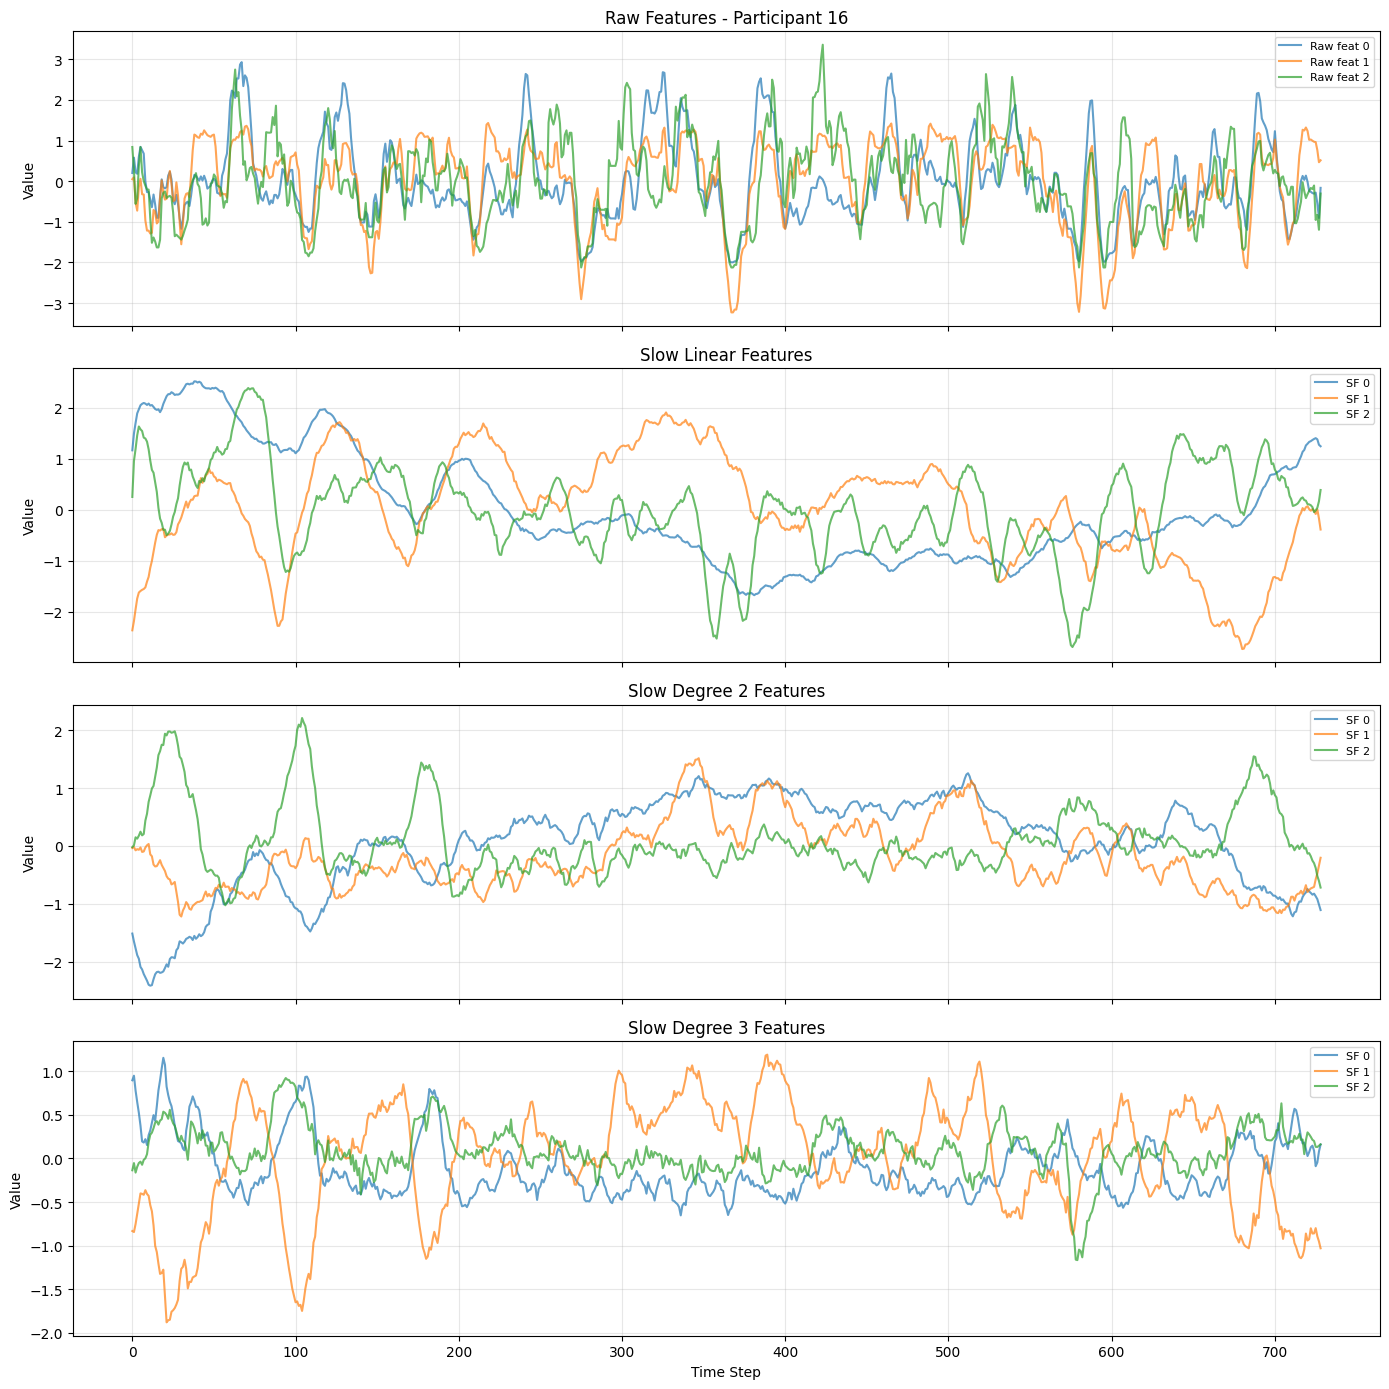

In [8]:
example_pid = np.unique(participant_ids)[0]
mask = participant_ids == example_pid
raw_example = X_scaled[mask]

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Raw features
for i in range(3):
    axes[0].plot(raw_example[:, i], alpha=0.7, label=f"Raw feat {i}")
axes[0].set_title(f"Raw Features - Participant {int(example_pid)}")
axes[0].set_ylabel("Value")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(alpha=0.3)

# Slow linear
sf = slow_linear_features[30][mask]
for i in range(3):
    axes[1].plot(sf[:, i], alpha=0.7, label=f"SF {i}")
axes[1].set_title("Slow Linear Features")
axes[1].set_ylabel("Value")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(alpha=0.3)

# Slow degree 2
sf = slow_deg2_features[30][mask]
for i in range(3):
    axes[2].plot(sf[:, i], alpha=0.7, label=f"SF {i}")
axes[2].set_title("Slow Degree 2 Features")
axes[2].set_ylabel("Value")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(alpha=0.3)

# Slow degree 3
sf = slow_deg3_features[30][mask]
for i in range(3):
    axes[3].plot(sf[:, i], alpha=0.7, label=f"SF {i}")
axes[3].set_title("Slow Degree 3 Features")
axes[3].set_xlabel("Time Step")
axes[3].set_ylabel("Value")
axes[3].legend(loc="upper right", fontsize=8)
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("features/temporal_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Participant-Aware Invariance Analysis

A key thesis claim is that SFA features should be more **invariant across participants**  
than raw features. We quantify this by computing the per-participant mean of each feature  
and measuring how much those means vary across participants (std of means).

Lower cross-participant variance suggests greater invariance.

In [9]:
def cross_participant_variance(features, participant_ids):
    """
    Compute the mean cross-participant variance of feature representations.

    For each feature dimension, compute the per-participant mean, then take the
    std of those means across participants. Average over all dimensions.

    Lower values = more invariant across participants.
    """
    unique_pids = np.unique(participant_ids)
    per_participant_means = []

    for pid in unique_pids:
        mask = participant_ids == pid
        per_participant_means.append(np.mean(features[mask], axis=0))

    per_participant_means = np.array(per_participant_means)
    return np.mean(np.std(per_participant_means, axis=0))


n_compare = 30

raw_cpv = cross_participant_variance(X_scaled[:, :n_compare], participant_ids)
lin_cpv = cross_participant_variance(slow_linear_features[n_compare], participant_ids)
deg2_cpv = cross_participant_variance(slow_deg2_features[n_compare], participant_ids)
deg3_cpv = cross_participant_variance(slow_deg3_features[n_compare], participant_ids)

print(f"Cross-Participant Variance ({n_compare} dimensions):")
print(f"  Raw features:       {raw_cpv:.6f}")
print(f"  Slow linear:        {lin_cpv:.6f}")
print(f"  Slow degree 2:      {deg2_cpv:.6f}")
print(f"  Slow degree 3:      {deg3_cpv:.6f}")

Cross-Participant Variance (30 dimensions):
  Raw features:       0.000000
  Slow linear:        0.000000
  Slow degree 2:      0.273318
  Slow degree 3:      0.182053


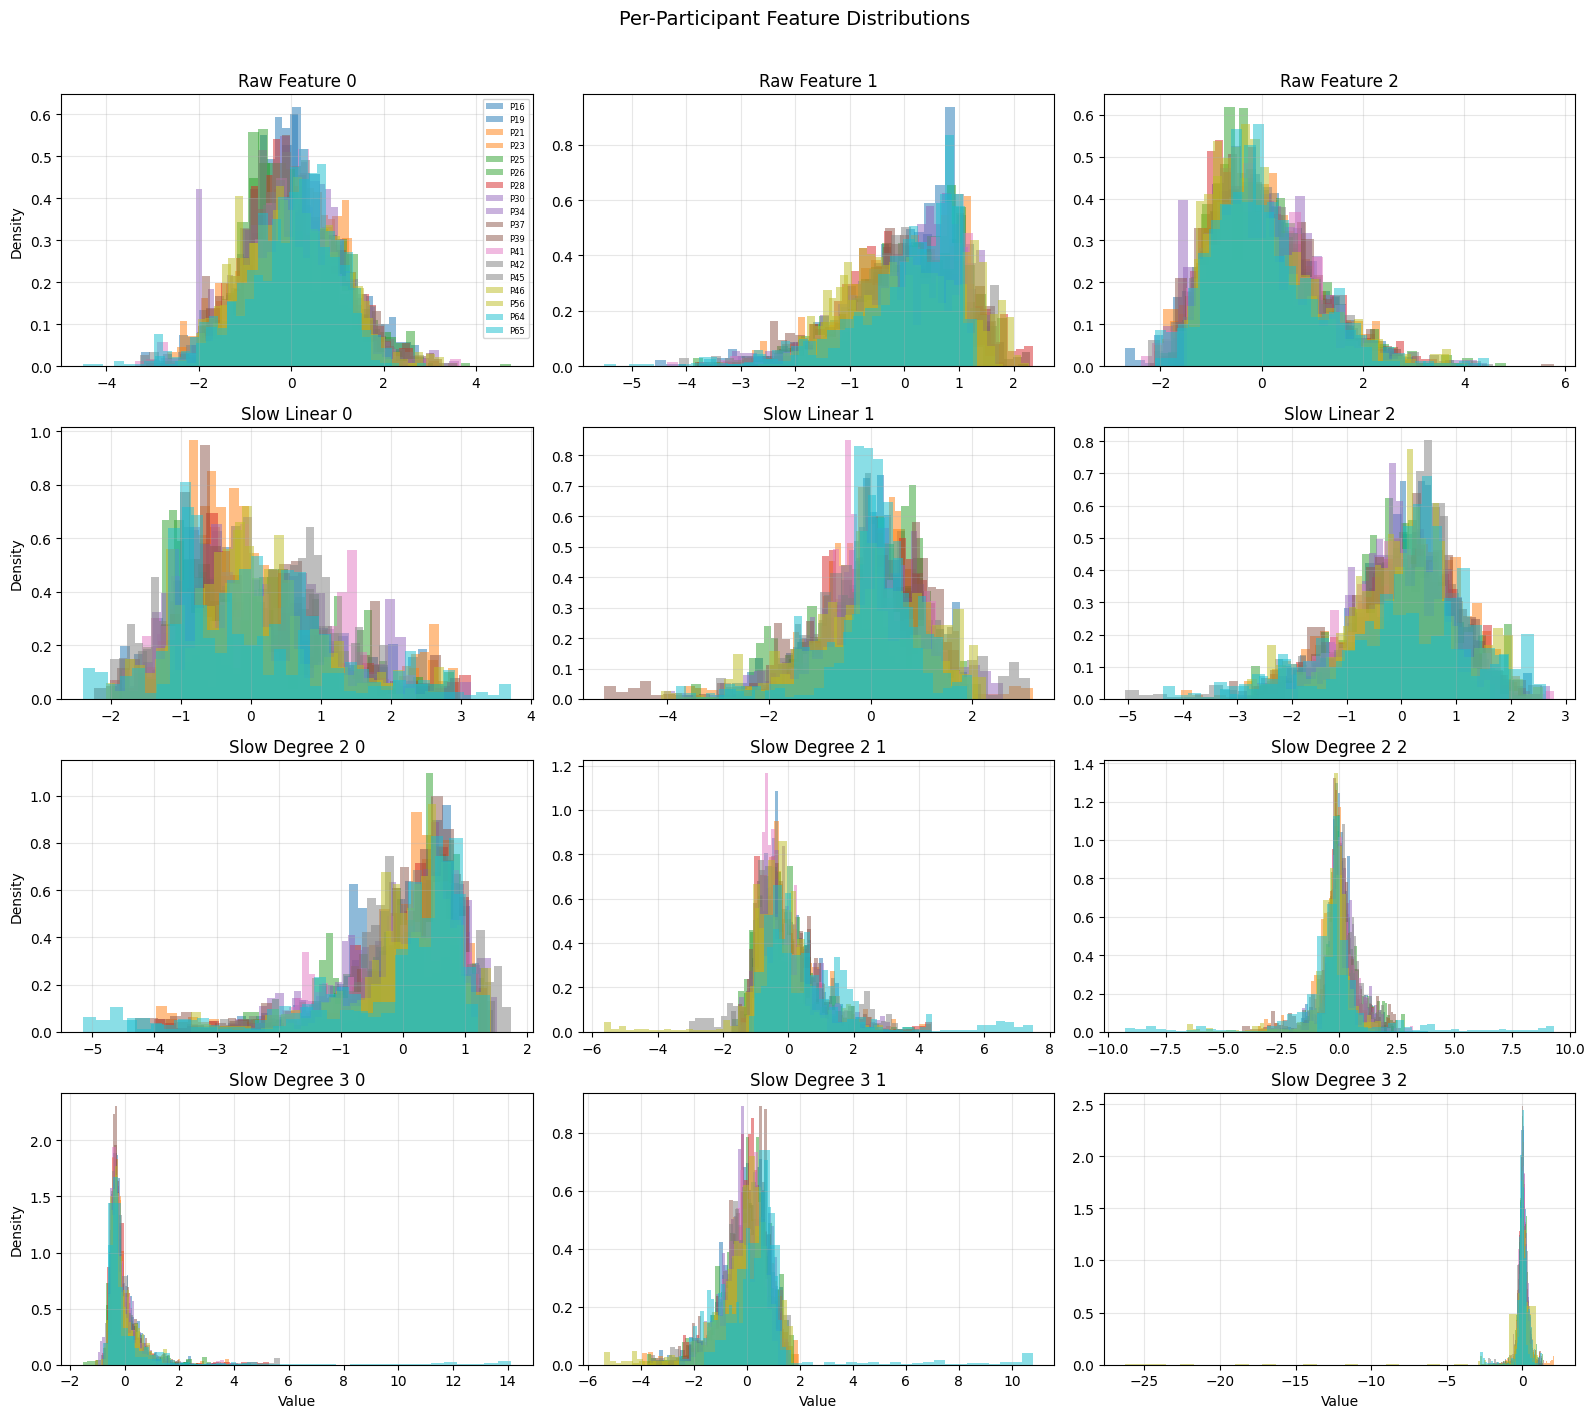

In [10]:
unique_pids = np.unique(participant_ids)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_pids)))

fig, axes = plt.subplots(4, 3, figsize=(16, 14))

row_data = [
    ("Raw Feature", X_scaled),
    ("Slow Linear", slow_linear_features[30]),
    ("Slow Degree 2", slow_deg2_features[30]),
    ("Slow Degree 3", slow_deg3_features[30]),
]

for row, (label, data) in enumerate(row_data):
    for col in range(3):
        ax = axes[row, col]
        for i, pid in enumerate(unique_pids):
            mask = participant_ids == pid
            ax.hist(data[mask, col], bins=30, alpha=0.5, color=colors[i],
                    label=f"P{int(pid)}", density=True)
        ax.set_title(f"{label} {col}")
        ax.grid(alpha=0.3)
        if col == 0 and row == 0:
            ax.legend(fontsize=6)
        if col == 0:
            ax.set_ylabel("Density")
        if row == 3:
            ax.set_xlabel("Value")

plt.suptitle("Per-Participant Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("features/participant_invariance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save All Feature Sets

Save all three SFA variants at all output dimensions.  
Naming convention:
- `slow_linear_{feature_label}_{dim}.npy`
- `slow_deg2_{feature_label}_{dim}.npy`
- `slow_deg3_{feature_label}_{dim}.npy`

In [11]:
os.makedirs("features", exist_ok=True)

for n_dim in output_dims:
    # Slow linear
    fname = f"features/slow_linear_{feature_label}_{n_dim}.npy"
    np.save(fname, slow_linear_features[n_dim])
    print(f"Saved: {fname}  shape={slow_linear_features[n_dim].shape}")

    # Slow degree 2
    fname = f"features/slow_deg2_{feature_label}_{n_dim}.npy"
    np.save(fname, slow_deg2_features[n_dim])
    print(f"Saved: {fname}  shape={slow_deg2_features[n_dim].shape}")

    # Slow degree 3
    fname = f"features/slow_deg3_{feature_label}_{n_dim}.npy"
    np.save(fname, slow_deg3_features[n_dim])
    print(f"Saved: {fname}  shape={slow_deg3_features[n_dim].shape}")

print(f"\nTotal files saved: {len(output_dims) * 3}")

Saved: features/slow_linear_all_5.npy  shape=(13066, 5)
Saved: features/slow_deg2_all_5.npy  shape=(13066, 5)
Saved: features/slow_deg3_all_5.npy  shape=(13066, 5)
Saved: features/slow_linear_all_10.npy  shape=(13066, 10)
Saved: features/slow_deg2_all_10.npy  shape=(13066, 10)
Saved: features/slow_deg3_all_10.npy  shape=(13066, 10)
Saved: features/slow_linear_all_15.npy  shape=(13066, 15)
Saved: features/slow_deg2_all_15.npy  shape=(13066, 15)
Saved: features/slow_deg3_all_15.npy  shape=(13066, 15)
Saved: features/slow_linear_all_20.npy  shape=(13066, 20)
Saved: features/slow_deg2_all_20.npy  shape=(13066, 20)
Saved: features/slow_deg3_all_20.npy  shape=(13066, 20)
Saved: features/slow_linear_all_25.npy  shape=(13066, 25)
Saved: features/slow_deg2_all_25.npy  shape=(13066, 25)
Saved: features/slow_deg3_all_25.npy  shape=(13066, 25)
Saved: features/slow_linear_all_30.npy  shape=(13066, 30)
Saved: features/slow_deg2_all_30.npy  shape=(13066, 30)
Saved: features/slow_deg3_all_30.npy  shap

In [12]:
# Summary: list all saved feature files
print("All feature files:")
for f in sorted(os.listdir("features")):
    if f.endswith(".npy"):
        arr = np.load(f"features/{f}")
        print(f"  {f:45s}  shape={arr.shape}")

All feature files:
  participant_ids.npy                            shape=(13066,)
  raw_features.npy                               shape=(13066, 288)
  slow_deg2_all_10.npy                           shape=(13066, 10)
  slow_deg2_all_15.npy                           shape=(13066, 15)
  slow_deg2_all_20.npy                           shape=(13066, 20)
  slow_deg2_all_25.npy                           shape=(13066, 25)
  slow_deg2_all_30.npy                           shape=(13066, 30)
  slow_deg2_all_5.npy                            shape=(13066, 5)
  slow_deg2_audio_10.npy                         shape=(13066, 10)
  slow_deg2_audio_15.npy                         shape=(13066, 15)
  slow_deg2_audio_20.npy                         shape=(13066, 20)
  slow_deg2_audio_25.npy                         shape=(13066, 25)
  slow_deg2_audio_30.npy                         shape=(13066, 30)
  slow_deg2_audio_5.npy                          shape=(13066, 5)
  slow_deg3_all_10.npy                         